Name: Samin Thapa

ID: 2408644

## Part 1: MNIST Denoising Autoencoder
### Step 1: Load, Preprocess and Add Noise to MNIST

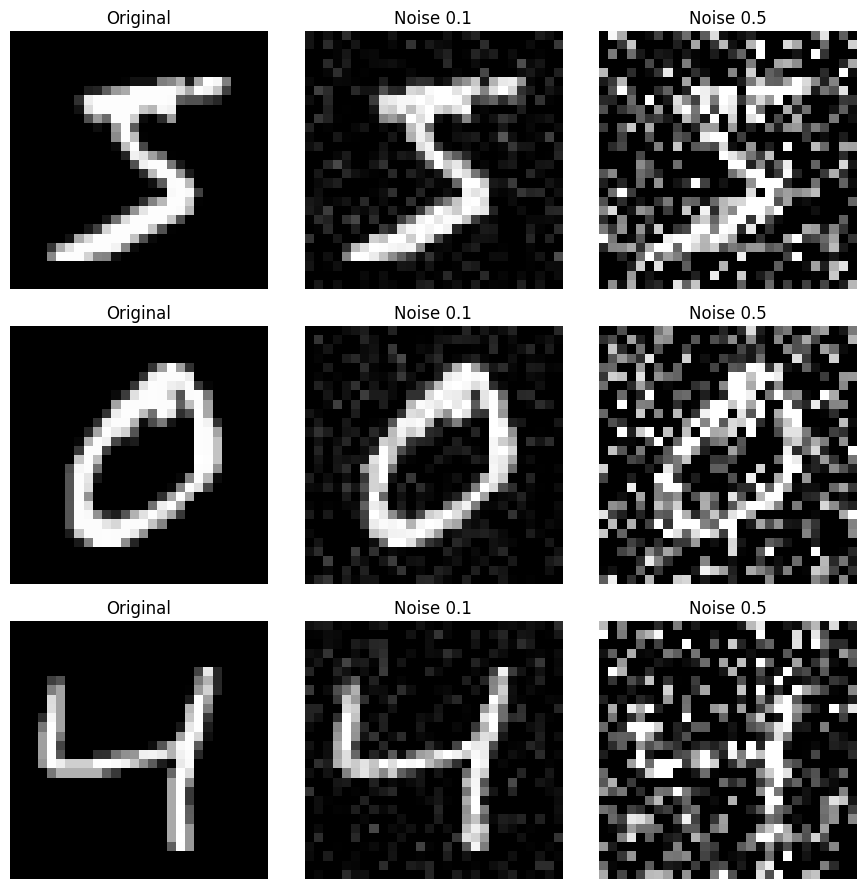

Training set shape: (60000, 28, 28, 1)
Test set shape: (10000, 28, 28, 1)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load and preprocess MNIST
(x_train_mnist_clean, y_train_mnist_labels), (x_test_mnist_clean, y_test_mnist_labels) = mnist.load_data()
x_train_mnist_clean = x_train_mnist_clean.astype('float32') / 255.
x_test_mnist_clean = x_test_mnist_clean.astype('float32') / 255.
x_train_mnist_clean = np.reshape(x_train_mnist_clean, (len(x_train_mnist_clean), 28, 28, 1))
x_test_mnist_clean = np.reshape(x_test_mnist_clean, (len(x_test_mnist_clean), 28, 28, 1))

# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train_mnist_clean + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train_mnist_clean.shape)
x_train_noisy_high = x_train_mnist_clean + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train_mnist_clean.shape)
x_test_noisy_low = x_test_mnist_clean + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test_mnist_clean.shape)
x_test_noisy_high = x_test_mnist_clean + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test_mnist_clean.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

# Visualize in a 3x3 grid
n = 3
plt.figure(figsize=(9, 9))
for i in range(n):
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train_mnist_clean[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Training set shape: {x_train_mnist_clean.shape}")
print(f"Test set shape: {x_test_mnist_clean.shape}")

### Step 2: Build the Convolutional Denoising Autoencoder Model


In [26]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_encoder(input_shape=(28, 28, 1)):
  """
  Builds the encoder part of the convolutional autoencoder.
  Parameters:
  input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.
  Returns:
  input_img (Keras Input): Input layer of the model.
  encoded (Keras Tensor): Encoded representation after convolution and pooling.
  """
  input_img = Input(shape=input_shape, name="input")
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
  x = MaxPooling2D((2, 2), padding='same')(x)
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
  encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
  return input_img, encoded

In [27]:
def build_decoder(encoded_input):
  """
  Builds the decoder part of the convolutional autoencoder.
  Parameters:
  encoded_input (Keras Tensor): The output from the encoder.

  Returns:
  decoded (Keras Tensor): The reconstructed output after upsampling and
  convolution.
  """
  x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
  x = UpSampling2D((2, 2))(x)
  x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
  x = UpSampling2D((2, 2))(x)
  decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
  return decoded

In [28]:
def build_autoencoder():
  """
  Constructs and compiles the full convolutional autoencoder by connecting encoder and
  decoder.
  Returns:
  autoencoder (Keras Model): Compiled autoencoder model.
  """
  input_img, encoded_output = build_encoder()
  decoded_output = build_decoder(encoded_output)
  autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
  autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
  return autoencoder

In [29]:
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

### Step 3: Train the Autoencoder


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.1545 - val_loss: 0.1120
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1087 - val_loss: 0.1042
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1037 - val_loss: 0.1012
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1013 - val_loss: 0.0993
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0996 - val_loss: 0.0980
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0984 - val_loss: 0.0971
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0975 - val_loss: 0.0963
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0968 - val_loss: 0.0957
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0961 - val_loss: 0.0952
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0957 - val_loss: 0.0951


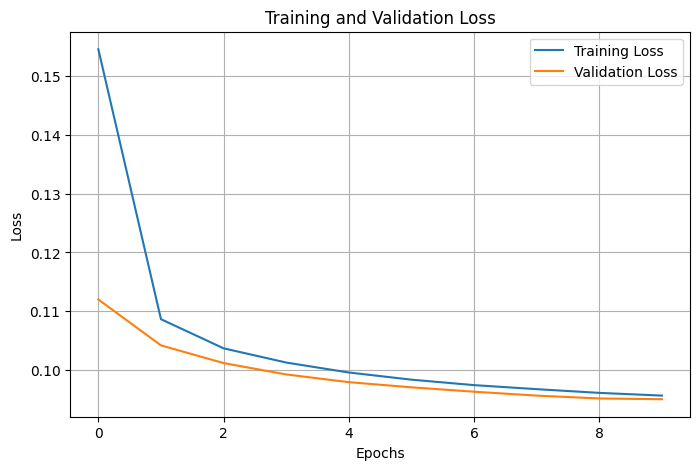

In [30]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()
# Train with noisy input and clean target
history = autoencoder.fit(
x_train_noisy_high, x_train,
epochs=10,
batch_size=128,
shuffle=True,
validation_data=(x_test_noisy_high, x_test)
)
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

###Step 4: Evaluate the Autoencoder:

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


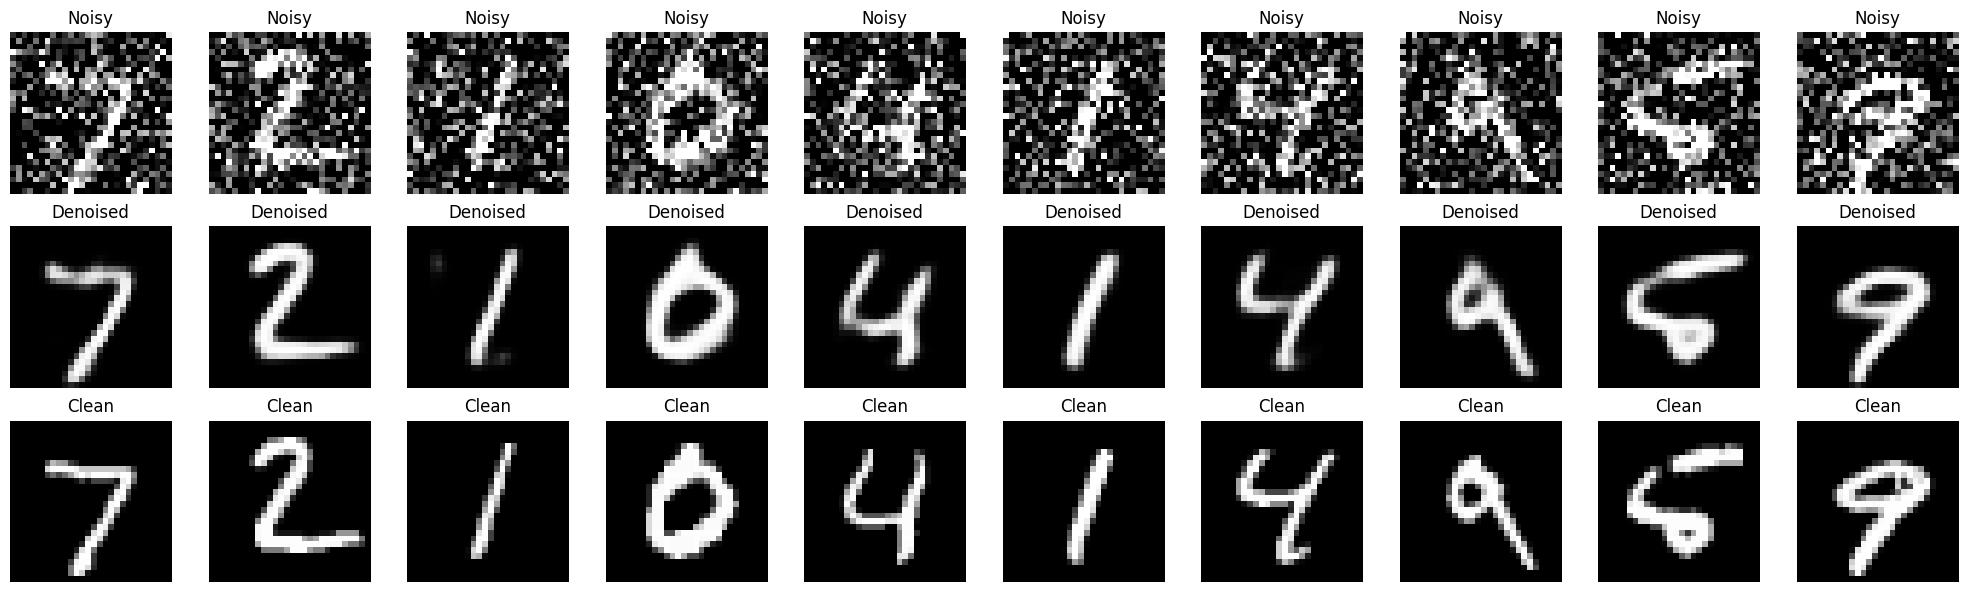

In [20]:
# Predict denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised")
        plt.axis('off')

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)


### Exercise: Build a Denoising Convolutional Autoencoder

### Step 1: Dataset Preparation and Preprocessin

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                      UpSampling2D, BatchNormalization)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.19.0


In [31]:
# Using MNIST dataset for Part 2

# Image dimensions (already 28, 28 for MNIST)
img_height, img_width = 28, 28

# Assign MNIST data loaded in Part 1 to Part 2's expected variables
x_train_full = x_train_mnist_clean
y_train_full = y_train_mnist_labels
x_test = x_test_mnist_clean # x_test variable is re-assigned
y_test = y_test_mnist_labels # y_test variable is assigned

print(f"Training set (MNIST): {x_train_full.shape}")
print(f"Test set (MNIST): {x_test.shape}")
print(f"Pixel value range: [{x_train_full.min():.2f}, {x_train_full.max():.2f}]")

Training set (MNIST): (60000, 28, 28, 1)
Test set (MNIST): (10000, 28, 28, 1)
Pixel value range: [0.00, 1.00]


In [32]:
# Split training data into train and validation sets (80/20)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print(f"Training samples: {x_train.shape[0]}")
print(f"Validation samples: {x_val.shape[0]}")
print(f"Test samples: {x_test.shape[0]}")

Training samples: 48000
Validation samples: 12000
Test samples: 10000


### Add Gaussian Noise and Visualize

In [33]:
# Add Gaussian noise to the images
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy = x_val + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Also create low-noise versions for comparison
noise_factor_low = 0.1
x_train_noisy_low = np.clip(x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape), 0., 1.)

print(f"Noisy training set shape: {x_train_noisy.shape}")
print(f"Noisy validation set shape: {x_val_noisy.shape}")
print(f"Noisy test set shape: {x_test_noisy.shape}")


Noisy training set shape: (48000, 28, 28, 1)
Noisy validation set shape: (12000, 28, 28, 1)
Noisy test set shape: (10000, 28, 28, 1)


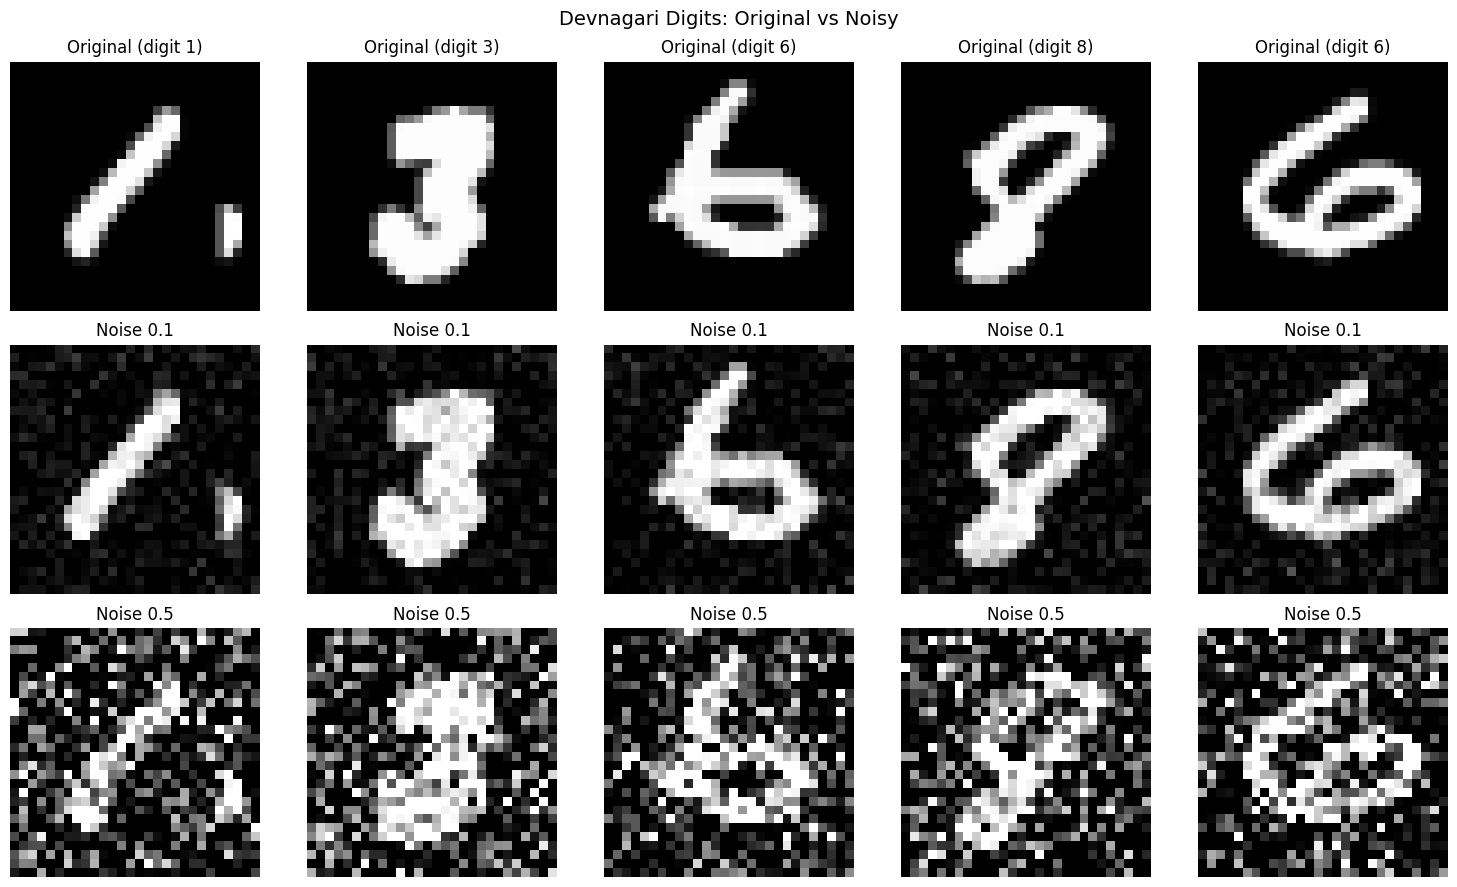

In [34]:
# Visualize original vs noisy images
n = 5
plt.figure(figsize=(15, 9))

for i in range(n):
    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_train[i].reshape(img_height, img_width), cmap='gray')
    plt.title(f"Original (digit {y_train[i]})")
    plt.axis('off')

    # Low noise
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_train_noisy_low[i].reshape(img_height, img_width), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_train_noisy[i].reshape(img_height, img_width), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.suptitle("Devnagari Digits: Original vs Noisy", fontsize=14)
plt.tight_layout()
plt.show()


### Step 2: Build the Deep Denoising Convolutional Autoencoder (4+ Layers)

In [35]:
def build_deep_encoder(input_shape=(28, 28, 1)):
    """
    Builds a deep encoder with 4 convolutional layers.

    Architecture:
        Conv2D(32) -> BN -> Conv2D(32) -> BN -> MaxPool(2x2)
        Conv2D(64) -> BN -> Conv2D(64) -> BN -> MaxPool(2x2)

    Output shape: (7, 7, 64)
    """
    input_img = Input(shape=input_shape, name="encoder_input")

    # Block 1: 28x28x1 -> 14x14x32
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv1')(input_img)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='enc_conv2')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same', name='enc_pool1')(x)

    # Block 2: 14x14x32 -> 7x7x64
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv3')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='enc_conv4')(x)
    x = BatchNormalization()(x)
    encoded = MaxPooling2D((2, 2), padding='same', name='latent_space')(x)

    return input_img, encoded


def build_deep_decoder(encoded_input):
    """
    Builds a deep decoder with 4 convolutional layers.

    Architecture:
        Conv2D(64) -> BN -> Conv2D(64) -> BN -> UpSample(2x2)
        Conv2D(32) -> BN -> Conv2D(32) -> BN -> UpSample(2x2)
        Conv2D(1, sigmoid)

    Output shape: (28, 28, 1)
    """
    # Block 1: 7x7x64 -> 14x14x64
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv1')(encoded_input)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same', name='dec_conv2')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2), name='dec_upsample1')(x)

    # Block 2: 14x14x64 -> 28x28x32
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv3')(x)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same', name='dec_conv4')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2), name='dec_upsample2')(x)

    # Output layer: sigmoid to keep pixel values in [0, 1]
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='reconstructed_output')(x)

    return decoded


def build_deep_autoencoder():
    """
    Constructs and compiles the full deep denoising autoencoder.
    Total: 4 conv layers in encoder + 4 conv layers in decoder + 1 output conv = 9 conv layers.
    """
    input_img, encoded_output = build_deep_encoder()
    decoded_output = build_deep_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="deep_denoising_autoencoder")
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

    return autoencoder


# Build and display summary
deep_autoencoder = build_deep_autoencoder()
deep_autoencoder.summary()


Model: "deep_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv1 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv2 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_pool1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv3 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_conv4 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv1 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv2 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample1 (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv3 (Conv2D)              │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_conv4 (Conv2D)              │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_upsample2 (UpSampling2D)    │ (None, 28, 28, 32)     │             

 Total params: 168,385 (657.75 KB)

 Trainable params: 167,617 (654.75 KB)

 Non-trainable params: 768 (3.00 KB)

### Step 3: Train the Denoising Autoencoder

In [36]:
# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_denoising_autoencoder.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the model
history = deep_autoencoder.fit(
    x_train_noisy, x_train,           # noisy input -> clean target
    epochs=30,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),
    callbacks=[early_stop, checkpoint]
)

print("\nTraining complete.")


Epoch 1/30
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2929
Epoch 1: val_loss improved from None to 0.15869, saving model to best_denoising_autoencoder.keras

Epoch 1: finished saving model to best_denoising_autoencoder.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - loss: 0.1715 - val_loss: 0.1587
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0989
Epoch 2: val_loss improved from 0.15869 to 0.09620, saving model to best_denoising_autoencoder.keras

Epoch 2: finished saving model to best_denoising_autoencoder.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0980 - val_loss: 0.0962
Epoch 3/30
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0951
Epoch 3: val_loss improved from 0.09620 to 0.09413, saving model to best_denoising_autoencoder.keras

Epoch 3: finished saving model to best_denoising_autoencoder.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0950 - val_loss: 0.0941
Epoch 4/30
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.

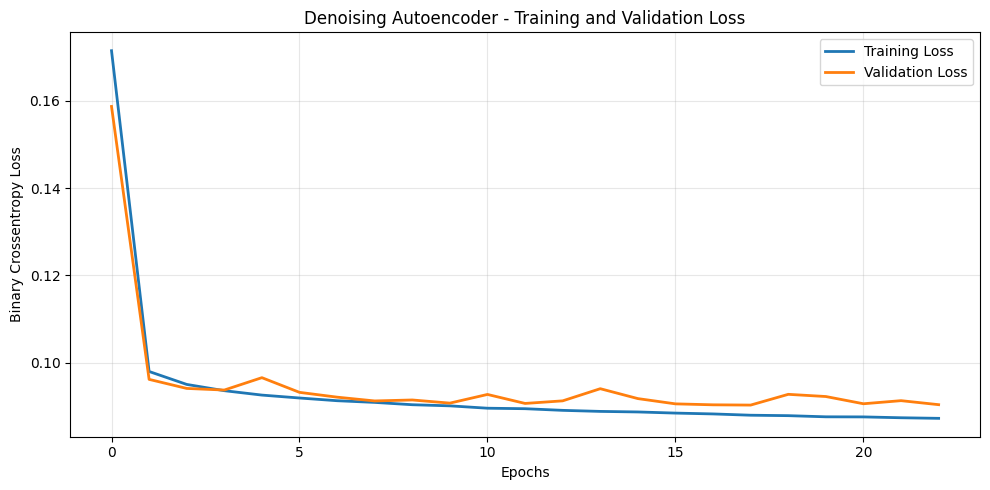

Final Training Loss: 0.0873
Final Validation Loss: 0.0904


In [37]:
# Plot training and validation loss curves
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Denoising Autoencoder - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print final loss values
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}")


### Step 4: Evaluate and Visualize the Results

In [38]:
# Evaluate on test set
test_loss = deep_autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"Test Loss (Binary Crossentropy): {test_loss:.4f}")

# Generate denoised images
denoised_test = deep_autoencoder.predict(x_test_noisy)
print(f"Denoised output shape: {denoised_test.shape}")


Test Loss (Binary Crossentropy): 0.0900
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Denoised output shape: (10000, 28, 28, 1)


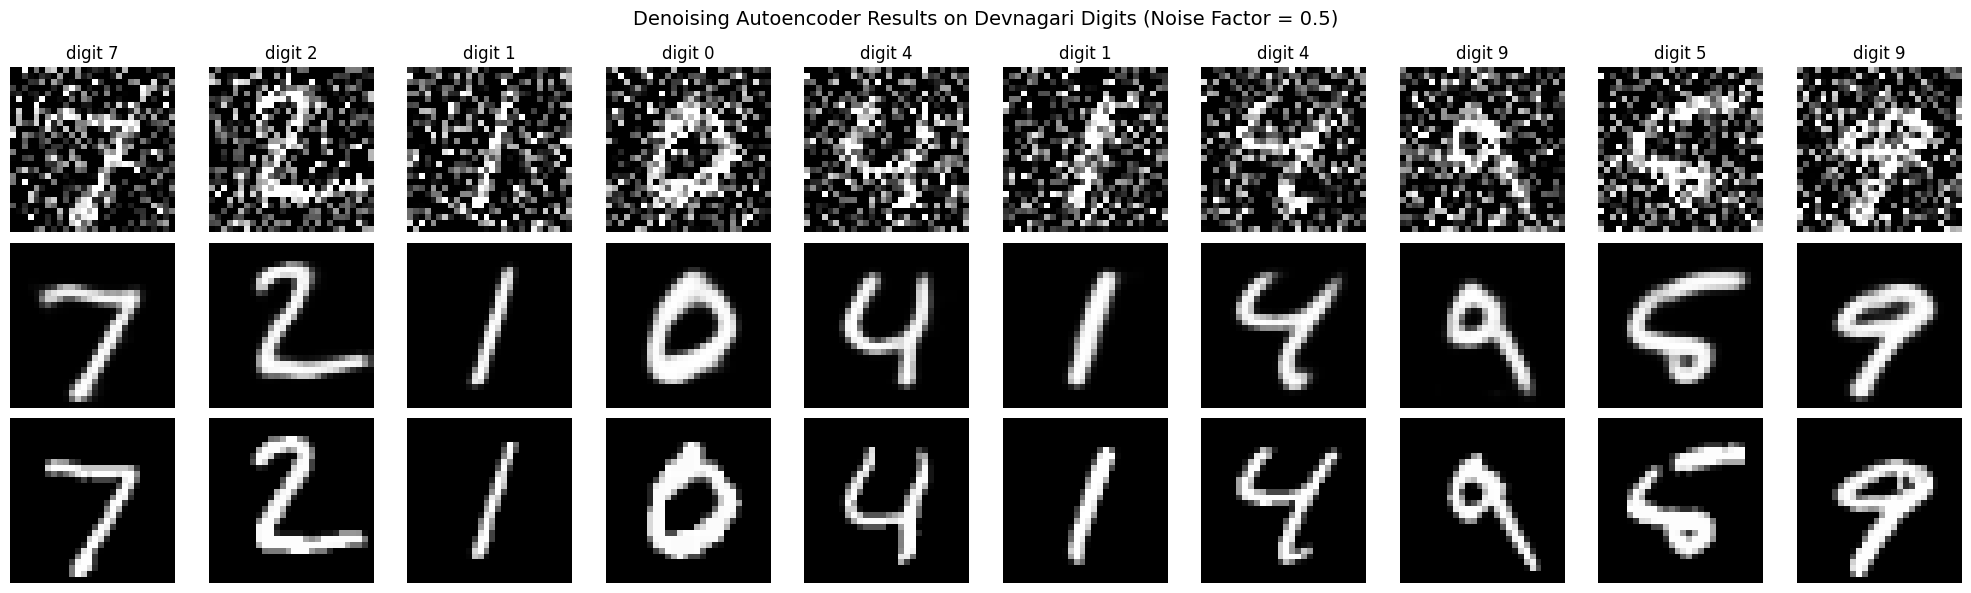

In [39]:
# Visualize: Noisy -> Denoised -> Clean
n = 10
plt.figure(figsize=(20, 6))

for i in range(n):
    # Noisy image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(img_height, img_width), cmap='gray')
    if i == 0:
        plt.ylabel("Noisy", fontsize=12)
    plt.title(f"digit {y_test[i]}")
    plt.axis('off')

    # Denoised image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_test[i].reshape(img_height, img_width), cmap='gray')
    if i == 0:
        plt.ylabel("Denoised", fontsize=12)
    plt.axis('off')

    # Clean image
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].reshape(img_height, img_width), cmap='gray')
    if i == 0:
        plt.ylabel("Clean", fontsize=12)
    plt.axis('off')

plt.suptitle("Denoising Autoencoder Results on Devnagari Digits (Noise Factor = 0.5)", fontsize=14)
plt.tight_layout()
plt.show()


### Step 5: Experiment and Fine - Tune the Model

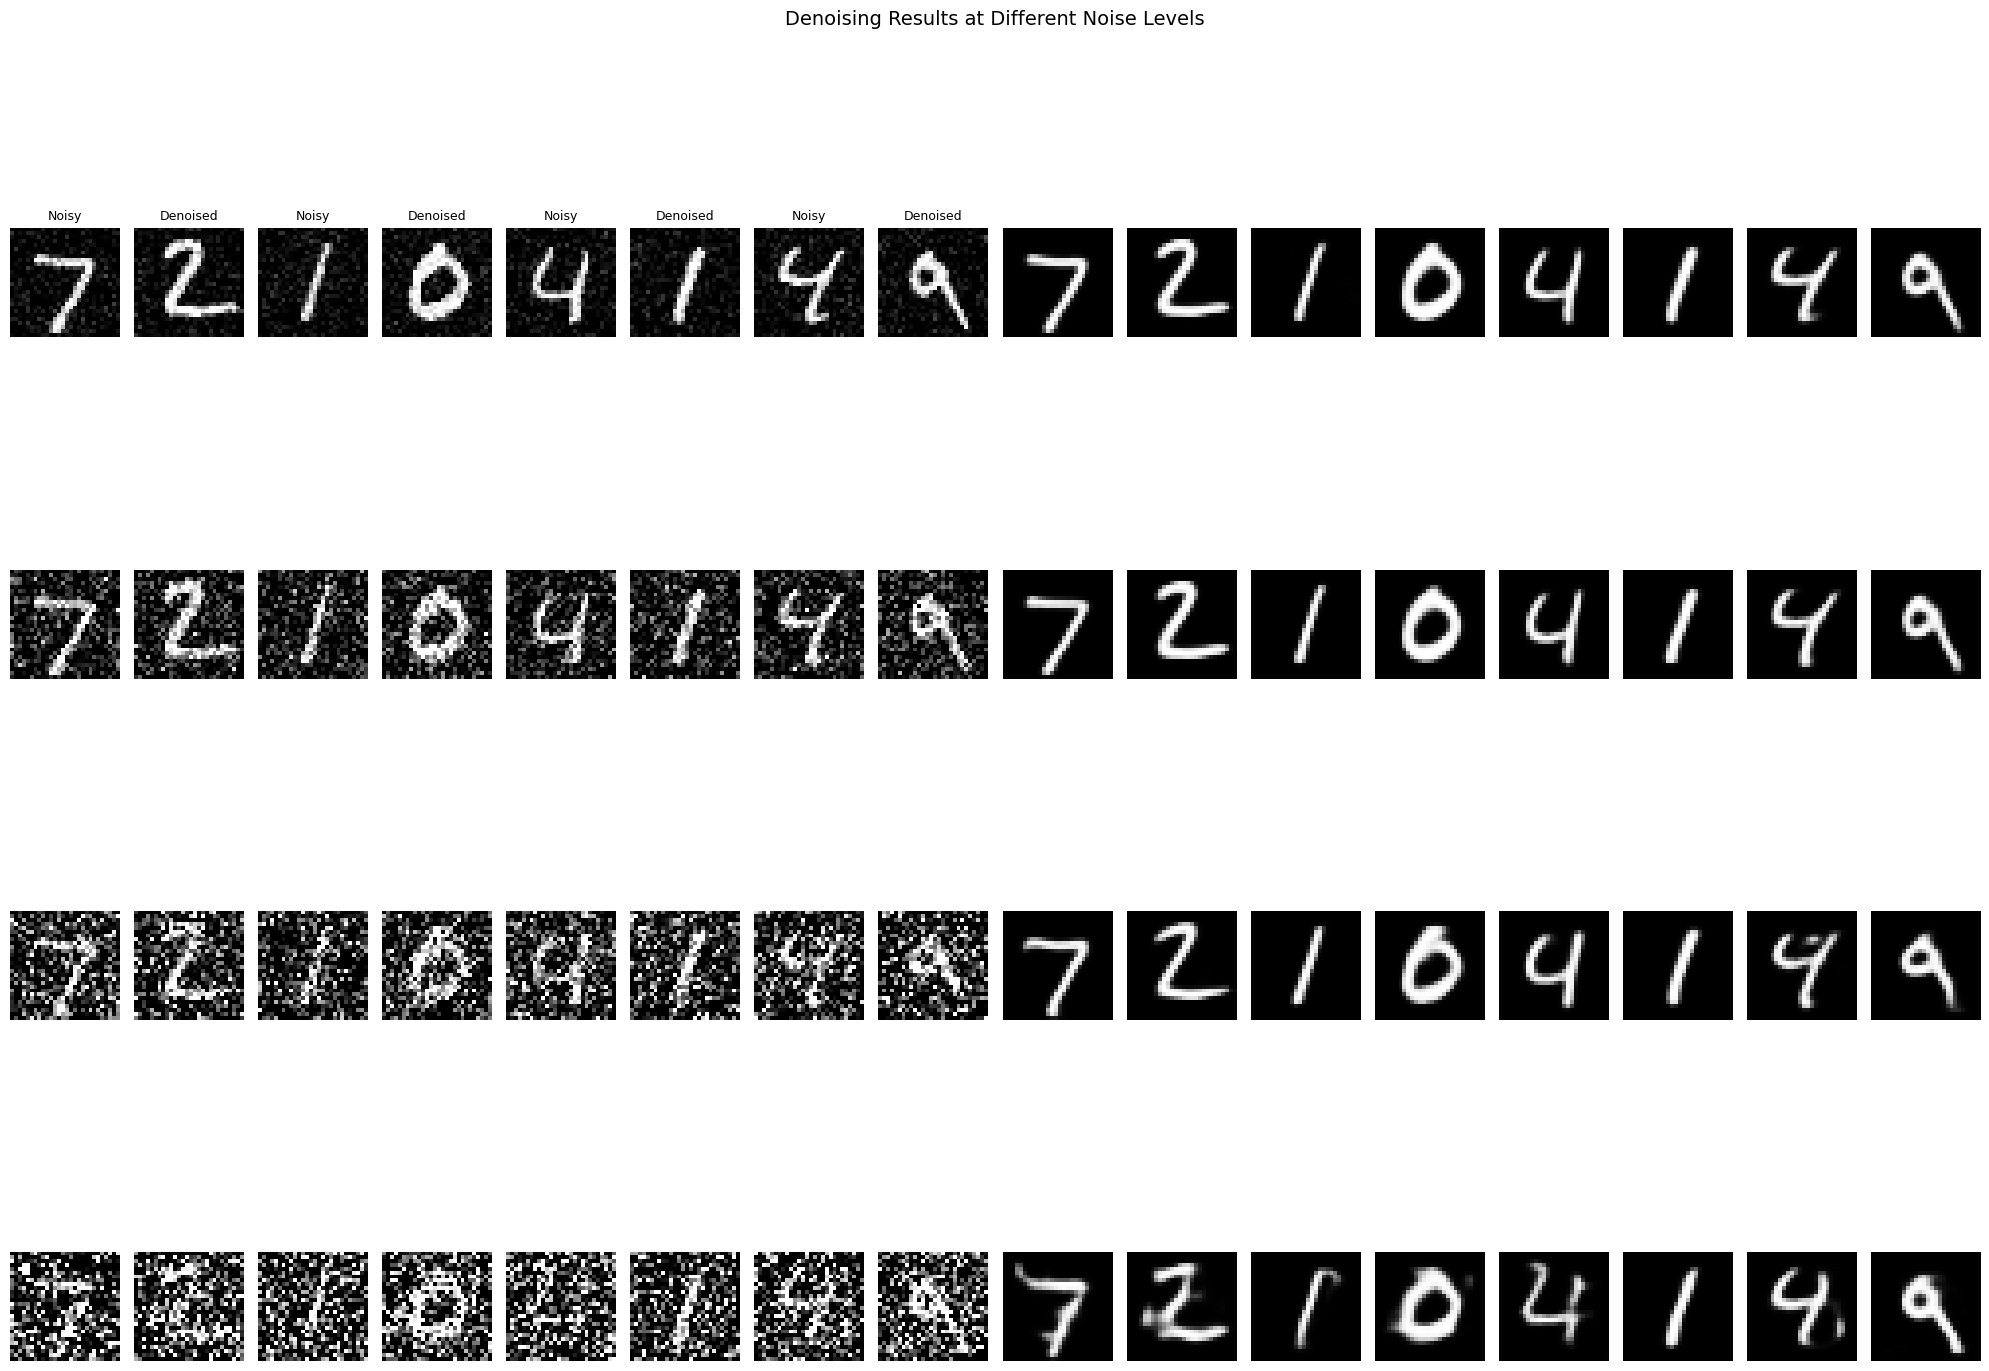

In [40]:
# Test the trained model on different noise levels
noise_levels = [0.1, 0.3, 0.5, 0.7]

plt.figure(figsize=(20, 4 * len(noise_levels)))

for row, nf in enumerate(noise_levels):
    # Generate noisy test images at this noise level
    x_test_noisy_exp = np.clip(
        x_test + nf * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape),
        0., 1.
    )
    denoised_exp = deep_autoencoder.predict(x_test_noisy_exp, verbose=0)

    # Compute MSE
    mse_exp = np.mean((denoised_exp - x_test) ** 2)

    n_show = 8
    for i in range(n_show):
        # Noisy
        plt.subplot(len(noise_levels), n_show * 2, row * n_show * 2 + i + 1)
        plt.imshow(x_test_noisy_exp[i].reshape(img_height, img_width), cmap='gray')
        if i == 0:
            plt.ylabel(f"Noise={nf}\nMSE={mse_exp:.4f}", fontsize=10)
        plt.axis('off')
        if row == 0:
            plt.title("Noisy" if i % 2 == 0 else "Denoised", fontsize=9)

        # Denoised
        plt.subplot(len(noise_levels), n_show * 2, row * n_show * 2 + i + 1 + n_show)
        plt.imshow(denoised_exp[i].reshape(img_height, img_width), cmap='gray')
        plt.axis('off')

plt.suptitle("Denoising Results at Different Noise Levels", fontsize=14)
plt.tight_layout()
plt.show()
